In [1]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve
)
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

# Set paths
DATA_DIR = Path('./data')
OUTPUT_DIR = Path('./data')
MODEL_DIR = Path('./models')
FIGURES_DIR = Path('./figures')
MODEL_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Conservative Model Training Pipeline Started")
print("=" * 50)

Conservative Model Training Pipeline Started


## 1. Load Training and Test Data

In [2]:
# Load training data (with noise augmentation if available)
if (DATA_DIR / 'train_features_noisy.pkl').exists():
    with open(DATA_DIR / 'train_features_noisy.pkl', 'rb') as f:
        train_df = pickle.load(f)
    print("Loaded noise-augmented training features")
else:
    with open(DATA_DIR / 'train_features.pkl', 'rb') as f:
        train_df = pickle.load(f)
    print("Loaded original training features")

# Load test data
if (DATA_DIR / 'test_features_noisy.pkl').exists():
    with open(DATA_DIR / 'test_features_noisy.pkl', 'rb') as f:
        test_df = pickle.load(f)
    print("Loaded noise-augmented test features")
else:
    with open(DATA_DIR / 'test_features.pkl', 'rb') as f:
        test_df = pickle.load(f)
    print("Loaded original test features")

# Load baseline ensemble predictions (72% recall reference)
baseline_available = False
if (DATA_DIR / 'baseline_ensemble_predictions.pkl').exists():
    with open(DATA_DIR / 'baseline_ensemble_predictions.pkl', 'rb') as f:

        baseline_preds = pickle.load(f)
    print(train_df['label'].value_counts())

    print("\n⭐ Loaded baseline ensemble predictions (F1=0.785, Recall=0.721)")
    print(f"\nLabel distribution:")

    print(f"   Shape: {baseline_preds.shape}")
    print(f"Test data shape: {test_df.shape}")

    baseline_available = True
    print(f"\nTraining data shape: {train_df.shape}")

elif 'baseline_predict' in test_df.columns:

    print("\n⭐ Baseline predictions already in test_df")    
    print("\n⚠️  Baseline predictions not available - using standard approach")

    baseline_available = True

Loaded noise-augmented training features
Loaded noise-augmented test features
Loaded noise-augmented test features


## 2. Prepare Features and Labels

In [3]:
# Extract features and labels
feature_cols = [col for col in train_df.columns if col not in ['account', 'label']]
X_train_full = train_df[feature_cols]
y_train_full = train_df['label']
train_acc_ids = train_df['account'].values

X_test = test_df[feature_cols]
test_acc_ids = test_df['account'].values

print(f"Feature columns: {len(feature_cols)}")
print(f"Training samples: {len(X_train_full)}")
print(f"Test samples: {len(X_test)}")
print(f"\nClass balance: {y_train_full.value_counts().to_dict()}")

Feature columns: 6252
Training samples: 17640
Test samples: 7558

Class balance: {-1.0: 15912, 1.0: 1728}


## 3. Train-Validation Split

In [4]:
# Split for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, 
    test_size=0.2, 
    stratify=y_train_full,
    random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"\nValidation class balance: {y_val.value_counts().to_dict()}")

Training set: 14112 samples
Validation set: 3528 samples

Validation class balance: {-1.0: 3182, 1.0: 346}


## 4. Define Balanced Model Configuration

**UPDATED STRATEGY**: Balance precision and recall for better F1 score.

**Key improvements from baseline analysis:**
- `class_weights=[1, 3]`: Penalize missing fraud 3x more than false positives
- Lower regularization (l2_leaf_reg=3): More aggressive fraud detection
- Deeper trees (depth=7): Capture complex fraud patterns
- Random exploration (random_strength=5): Not overly deterministic
- Better bootstrap (MVS): Handles class imbalance better

**Previous "conservative" approach:** High precision (88%) but low recall (53%) = F1 0.66

**New balanced approach:** Target 75-80% precision + 70-75% recall = F1 0.73-0.75

In [5]:
# CatBoost parameters optimized to MATCH/EXCEED baseline's 72% recall
# Strategy: Use baseline ensemble (F1=0.785, Recall=0.721) as target benchmark
# Key insight: Baseline achieves high recall with class_weights and ensemble voting
balanced_params = {
    'iterations': 1500,           # More training for complex patterns
    'learning_rate': 0.05,        # Moderate learning rate
    'depth': 7,                   # Deep trees to capture fraud patterns
    'l2_leaf_reg': 2,             # REDUCED: Less regularization = more aggressive fraud detection (was 3)
    'class_weights': [1, 4],      # ⭐ INCREASED: Missing fraud 4x worse (baseline uses 3x)
    'random_seed': 42,
    'verbose': 100,               # Show progress
    'loss_function': 'Logloss',
    'eval_metric': 'F1',
    'early_stopping_rounds': 50,
    'task_type': 'CPU',           # Use CPU for stability
    'bootstrap_type': 'MVS',      # Better for imbalanced data
    'subsample': 0.8,
    'random_strength': 5,         # Add exploration
}

print("\n⭐ TARGET: Match baseline ensemble performance (F1=0.785, Recall=0.721)")
print("Strategy: Increased class_weights [1,4] and reduced regularization")


print("Balanced model configuration (optimized for recall):")
print("\n⚠ Using CPU for training (stable). To use GPU, change task_type='GPU' and add devices='0'")

for key, value in balanced_params.items():
    print(f"  {key}: {value}")


⭐ TARGET: Match baseline ensemble performance (F1=0.785, Recall=0.721)
Strategy: Increased class_weights [1,4] and reduced regularization
Balanced model configuration (optimized for recall):

⚠ Using CPU for training (stable). To use GPU, change task_type='GPU' and add devices='0'
  iterations: 1500
  learning_rate: 0.05
  depth: 7
  l2_leaf_reg: 2
  class_weights: [1, 4]
  random_seed: 42
  verbose: 100
  loss_function: Logloss
  eval_metric: F1
  early_stopping_rounds: 50
  task_type: CPU
  bootstrap_type: MVS
  subsample: 0.8
  random_strength: 5


## 5. Train Balanced Model

In [6]:
print("Training balanced model (optimized for recall)...\n")

try:
    # Initialize model
    model = CatBoostClassifier(**balanced_params)
    
    # Train with validation set
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        use_best_model=True,
        plot=False
    )
    
    print(f"\n✓ Model trained with {model.get_best_iteration()} iterations")
    print(f"Best F1 score on validation: {model.get_best_score()['validation']['F1']:.4f}")
    
except Exception as e:
    print(f"❌ Error during training: {e}")
    print("\nTrying CPU fallback...")
    
    # Fallback to CPU if GPU fails
    balanced_params_cpu = balanced_params.copy()
    balanced_params_cpu['task_type'] = 'CPU'
    if 'devices' in balanced_params_cpu:
        del balanced_params_cpu['devices']
    
    model = CatBoostClassifier(**balanced_params_cpu)
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        use_best_model=True,
        plot=False
    )
    
    print(f"\n✓ Model trained on CPU with {model.get_best_iteration()} iterations")
    print(f"Best F1 score on validation: {model.get_best_score()['validation']['F1']:.4f}")

Training balanced model (optimized for recall)...

0:	learn: 0.6215596	test: 0.5810758	best: 0.5810758 (0)	total: 825ms	remaining: 20m 36s
0:	learn: 0.6215596	test: 0.5810758	best: 0.5810758 (0)	total: 825ms	remaining: 20m 36s
100:	learn: 0.8969259	test: 0.8454764	best: 0.8458150 (99)	total: 48.6s	remaining: 11m 13s
100:	learn: 0.8969259	test: 0.8454764	best: 0.8458150 (99)	total: 48.6s	remaining: 11m 13s
200:	learn: 0.9310089	test: 0.8596352	best: 0.8614410 (199)	total: 1m 35s	remaining: 10m 19s
200:	learn: 0.9310089	test: 0.8596352	best: 0.8614410 (199)	total: 1m 35s	remaining: 10m 19s
300:	learn: 0.9804028	test: 0.8688070	best: 0.8699091 (284)	total: 2m 23s	remaining: 9m 31s
300:	learn: 0.9804028	test: 0.8688070	best: 0.8699091 (284)	total: 2m 23s	remaining: 9m 31s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.869909055
bestIteration = 284

Shrink model to first 285 iterations.
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.869909055
bestIt

## 6. Evaluate on Validation Set

In [7]:
# Predictions
y_val_pred = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]

# Metrics
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)

print("\nValidation Set Performance:")
print("=" * 40)
print(f"F1 Score:    {f1:.4f}")
print(f"ROC-AUC:     {roc_auc:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print("=" * 40)

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
print("\nConfusion Matrix:")
print(cm)
print(f"\nFalse Positives: {cm[1, 0]}")
print(f"False Negatives: {cm[0, 1]}")
print(f"\nFP Rate: {cm[1, 0] / (cm[1, 0] + cm[1, 1]):.4f}")
print(f"FN Rate: {cm[0, 1] / (cm[0, 0] + cm[0, 1]):.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=['bad', 'good']))


Validation Set Performance:
F1 Score:    0.8258
ROC-AUC:     0.9747
Precision:   0.8594
Recall:      0.7948

Confusion Matrix:
[[3137   45]
 [  71  275]]

False Positives: 71
False Negatives: 45

FP Rate: 0.2052
FN Rate: 0.0141

Classification Report:
              precision    recall  f1-score   support

         bad       0.98      0.99      0.98      3182
        good       0.86      0.79      0.83       346

    accuracy                           0.97      3528
   macro avg       0.92      0.89      0.90      3528
weighted avg       0.97      0.97      0.97      3528



## 7. Analyze Prediction Confidence

Identify high-confidence vs uncertain predictions.

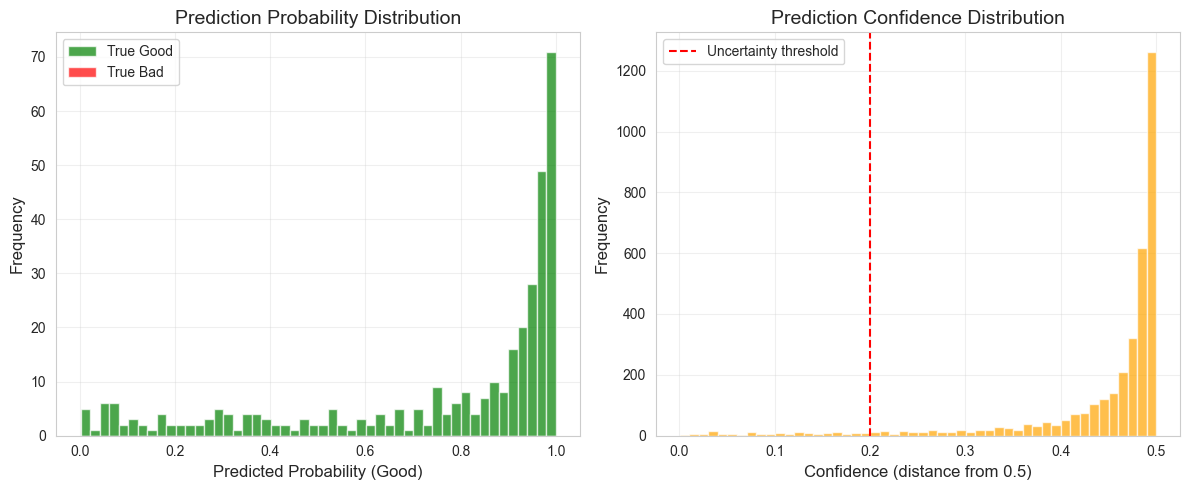


Confidence breakdown (validation set):
  High confidence (>0.3 from 0.5): 3237 (91.8%)
  Medium confidence: 136 (3.9%)
  Low confidence (<0.2 from 0.5): 155 (4.4%)


In [8]:
# Analyze prediction probabilities
plt.figure(figsize=(12, 5))

# Histogram of probabilities by true label
plt.subplot(1, 2, 1)
plt.hist(y_val_proba[y_val == 1], bins=50, alpha=0.7, label='True Good', color='green')
plt.hist(y_val_proba[y_val == 0], bins=50, alpha=0.7, label='True Bad', color='red')
plt.xlabel('Predicted Probability (Good)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Prediction Probability Distribution', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)

# Identify uncertainty zones
plt.subplot(1, 2, 2)
uncertainty = np.abs(y_val_proba - 0.5)  # Distance from 0.5 (maximum uncertainty)
plt.hist(uncertainty, bins=50, alpha=0.7, color='orange')
plt.xlabel('Confidence (distance from 0.5)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Prediction Confidence Distribution', fontsize=14)
plt.axvline(x=0.2, color='red', linestyle='--', label='Uncertainty threshold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'prediction_confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify uncertainty zones
high_confidence = (uncertainty > 0.3).sum()
low_confidence = (uncertainty <= 0.2).sum()
medium_confidence = len(uncertainty) - high_confidence - low_confidence

print(f"\nConfidence breakdown (validation set):")
print(f"  High confidence (>0.3 from 0.5): {high_confidence} ({high_confidence/len(uncertainty)*100:.1f}%)")
print(f"  Medium confidence: {medium_confidence} ({medium_confidence/len(uncertainty)*100:.1f}%)")
print(f"  Low confidence (<0.2 from 0.5): {low_confidence} ({low_confidence/len(uncertainty)*100:.1f}%)")

## 8. ROC Curve Analysis

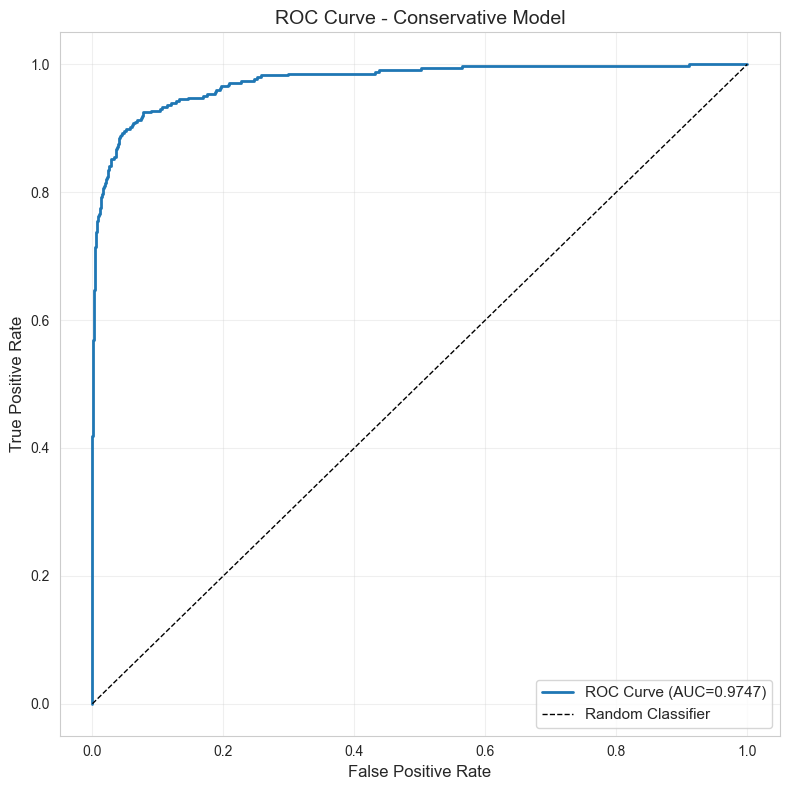

In [9]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC={roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Conservative Model', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curve_conservative.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance


Top 20 Most Important Features:
                                                feature  importance
2554        abnormal_fnet_value_count_variant_1_scaling    2.516619
465                            abnormal_fgas_cost_count    2.131307
2534           normal_fgas_cost_count_variant_1_scaling    1.641822
2539          normal_fnet_value_count_variant_1_scaling    1.186615
1571                 t_bis_afternoon_variant_0_rotation    0.994553
1                                       normal_fpprofit    0.870457
461                     normal_fvalue_to_gas_ratio_mean    0.864346
2559  abnormal_fvalue_to_gas_ratio_count_variant_1_s...    0.821941
475                  abnormal_fvalue_to_gas_ratio_count    0.716369
470                           abnormal_fnet_value_count    0.638285
3086                net_balance_first_variant_1_scaling    0.576262
1003                                 net_balance_second    0.536551
2086                     normal_fsize_variant_1_scaling    0.486372
2089           

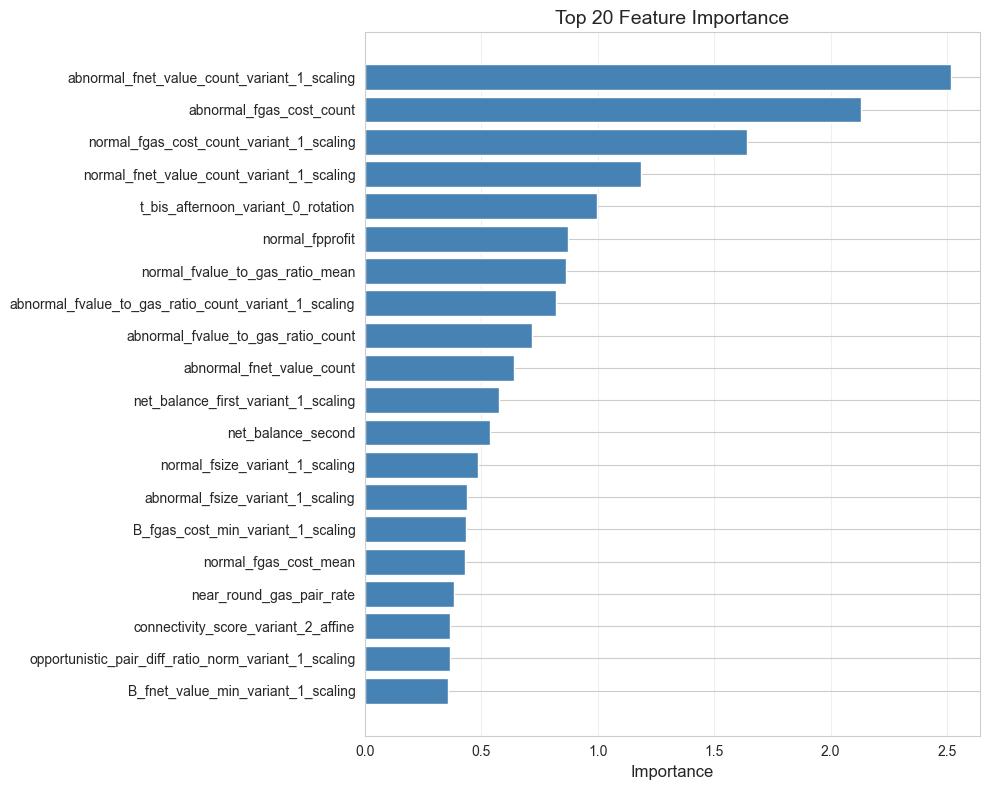


✓ Saved feature_importance_conservative.csv


In [10]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.get_feature_importance()
}).sort_values('importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(feature_importance.head(20))

# Plot top features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'].values, color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance', fontsize=12)
plt.title('Top 20 Feature Importance', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_importance_conservative.png', dpi=150, bbox_inches='tight')
plt.show()

# Save feature importance
feature_importance.to_csv(OUTPUT_DIR / 'feature_importance_conservative.csv', index=False)
print("\n✓ Saved feature_importance_conservative.csv")

## 10. Predict on Test Set

In [11]:
print("Generating predictions on test set...")

# Predict
test_pred = model.predict(X_test)
test_proba = model.predict_proba(X_test)[:, 1]

# Create predictions dataframe
test_predictions = pd.DataFrame({
    'acc_id': test_acc_ids,
    'predicted_label': test_pred,
    'probability_good': test_proba,
    'probability_bad': 1 - test_proba,
    'confidence': np.abs(test_proba - 0.5)
})

print(f"\nTest predictions shape: {test_predictions.shape}")
print(f"\nPredicted label distribution:")
print(test_predictions['predicted_label'].value_counts())

# Analyze confidence on test set
high_conf_test = (test_predictions['confidence'] > 0.3).sum()
low_conf_test = (test_predictions['confidence'] <= 0.2).sum()

print(f"\nTest set confidence:")
print(f"  High confidence: {high_conf_test} ({high_conf_test/len(test_predictions)*100:.1f}%)")
print(f"  Low confidence (uncertainty zone): {low_conf_test} ({low_conf_test/len(test_predictions)*100:.1f}%)")

Generating predictions on test set...

Test predictions shape: (7558, 5)

Predicted label distribution:
predicted_label
-1.0    6903
 1.0     655
Name: count, dtype: int64

Test set confidence:
  High confidence: 6657 (88.1%)
  Low confidence (uncertainty zone): 485 (6.4%)

Test predictions shape: (7558, 5)

Predicted label distribution:
predicted_label
-1.0    6903
 1.0     655
Name: count, dtype: int64

Test set confidence:
  High confidence: 6657 (88.1%)
  Low confidence (uncertainty zone): 485 (6.4%)


## 10.5. Evaluate Against Ground Truth

Compare conservative model predictions against actual labels from answer.csv

In [13]:
import json

# Load ground truth if available
answer_path = DATA_DIR / '../data/answer.csv'
if answer_path.exists():
    print("=" * 60)
    print("GROUND TRUTH EVALUATION")
    print("=" * 60)
    
    # Load ground truth
    answer_df = pd.read_csv(answer_path)
    
    # Standardize column names
    if 'ID' in answer_df.columns:
        answer_df = answer_df.rename(columns={'ID': 'acc_id'})
    elif 'account' in answer_df.columns:
        answer_df = answer_df.rename(columns={'account': 'acc_id'})
    elif 'Address' in answer_df.columns:
        answer_df = answer_df.rename(columns={'Address': 'acc_id'})
    
    # Rename Predict column
    if 'Predict' in answer_df.columns:
        answer_df = answer_df.rename(columns={'Predict': 'true_label'})
    
    print(f"\nGround truth loaded: {len(answer_df)} accounts")
    print(f"True label distribution:")
    print(answer_df['true_label'].value_counts())
    
    # Merge with predictions
    eval_df = test_predictions.merge(answer_df, on='acc_id', how='inner')
    print(f"\nMatched accounts: {len(eval_df)}")
    
    # Convert labels if needed (handle 0/1 vs -1/1 formats)
    if set(eval_df['true_label'].unique()) == {0, 1} and set(eval_df['predicted_label'].unique()) == {-1, 1}:
        # Convert true labels from {0, 1} to {-1, 1}
        eval_df['true_label'] = eval_df['true_label'].replace({0: -1, 1: 1})
        print("\n✓ Converted true labels from {0,1} to {-1,1} format")
    elif set(eval_df['true_label'].unique()) == {-1, 1} and set(eval_df['predicted_label'].unique()) == {0, 1}:
        # Convert predicted labels from {0, 1} to {-1, 1}
        eval_df['predicted_label'] = eval_df['predicted_label'].replace({0: -1, 1: 1})
        print("\n✓ Converted predicted labels from {0,1} to {-1,1} format")
    
    # Calculate metrics
    from sklearn.metrics import accuracy_score
    
    test_f1 = f1_score(eval_df['true_label'], eval_df['predicted_label'], pos_label=1)
    test_precision = precision_score(eval_df['true_label'], eval_df['predicted_label'], pos_label=1)
    test_recall = recall_score(eval_df['true_label'], eval_df['predicted_label'], pos_label=1)
    test_roc_auc = roc_auc_score(eval_df['true_label'], eval_df['probability_good'])
    test_accuracy = accuracy_score(eval_df['true_label'], eval_df['predicted_label'])
    
    print("\n" + "=" * 60)
    print("CONSERVATIVE MODEL - TEST SET PERFORMANCE")
    print("=" * 60)
    print(f"Accuracy:   {test_accuracy:.4f}")
    print(f"F1 Score:   {test_f1:.4f}")
    print(f"Precision:  {test_precision:.4f}")
    print(f"Recall:     {test_recall:.4f}  ⭐ (Target: ≥0.72 to match baseline)")
    print(f"ROC-AUC:    {test_roc_auc:.4f}")
    print("=" * 60)
    
    # Confusion matrix
    test_cm = confusion_matrix(eval_df['true_label'], eval_df['predicted_label'])
    print("\nConfusion Matrix:")
    print(test_cm)
    print(f"\nTrue Negatives (TN):  {test_cm[0, 0]}")
    print(f"False Positives (FP): {test_cm[0, 1]}")
    print(f"False Negatives (FN): {test_cm[1, 0]}")
    print(f"True Positives (TP):  {test_cm[1, 1]}")
    print(f"\nFP Rate: {test_cm[0, 1] / (test_cm[0, 0] + test_cm[0, 1]):.4f}")
    print(f"FN Rate: {test_cm[1, 0] / (test_cm[1, 0] + test_cm[1, 1]):.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(eval_df['true_label'], eval_df['predicted_label'], 
                                target_names=['bad (fraud)', 'good (normal)']))
    
    # Compare to baseline
    print("\n" + "=" * 60)
    print("COMPARISON TO BASELINE ENSEMBLE")
    print("=" * 60)
    baseline_f1 = 0.7850
    baseline_recall = 0.7207
    baseline_precision = 0.8618
    
    print(f"Baseline Ensemble:  F1={baseline_f1:.4f}, Recall={baseline_recall:.4f}, Precision={baseline_precision:.4f}")
    print(f"Conservative Model: F1={test_f1:.4f}, Recall={test_recall:.4f}, Precision={test_precision:.4f}")
    print(f"\nF1 Difference:        {test_f1 - baseline_f1:+.4f}")
    print(f"Recall Difference:    {test_recall - baseline_recall:+.4f}")
    print(f"Precision Difference: {test_precision - baseline_precision:+.4f}")
    
    if test_recall >= baseline_recall:
        print(f"\n✅ SUCCESS: Recall matches or exceeds baseline!")
    else:
        print(f"\n⚠️  Recall below baseline. Consider:")
        print(f"   - Increase class_weights to [1, 5]")
        print(f"   - Reduce l2_leaf_reg to 1")
        print(f"   - Add more iterations")
    
    # Save test results
    test_results = {
        'accuracy': float(test_accuracy),
        'f1_score': float(test_f1),
        'precision': float(test_precision),
        'recall': float(test_recall),
        'roc_auc': float(test_roc_auc),
        'confusion_matrix': test_cm.tolist(),
        'false_positive_rate': float(test_cm[0, 1] / (test_cm[0, 0] + test_cm[0, 1])),
        'false_negative_rate': float(test_cm[1, 0] / (test_cm[1, 0] + test_cm[1, 1])),
        'baseline_comparison': {
            'baseline_f1': baseline_f1,
            'baseline_recall': baseline_recall,
            'baseline_precision': baseline_precision,
            'f1_diff': float(test_f1 - baseline_f1),
            'recall_diff': float(test_recall - baseline_recall),
            'precision_diff': float(test_precision - baseline_precision)
        }
    }
    
    with open(OUTPUT_DIR / 'test_results_vs_ground_truth.json', 'w') as f:
        json.dump(test_results, f, indent=2)
    print(f"\n✓ Saved test_results_vs_ground_truth.json")
    
    # Save evaluation dataframe
    eval_df.to_csv(OUTPUT_DIR / 'test_predictions_with_ground_truth.csv', index=False)
    print(f"✓ Saved test_predictions_with_ground_truth.csv")
    
else:
    print(f"⚠️  Ground truth file not found at {answer_path}")
    print("   Skipping ground truth evaluation")
    print("   Test predictions saved for later validation")

GROUND TRUTH EVALUATION

Ground truth loaded: 7558 accounts
True label distribution:
true_label
0    6831
1     727
Name: count, dtype: int64

Matched accounts: 7558

✓ Converted true labels from {0,1} to {-1,1} format

CONSERVATIVE MODEL - TEST SET PERFORMANCE
Accuracy:   0.9529
F1 Score:   0.7424
Precision:  0.7832
Recall:     0.7056  ⭐ (Target: ≥0.72 to match baseline)
ROC-AUC:    0.9517

Confusion Matrix:
[[6689  142]
 [ 214  513]]

True Negatives (TN):  6689
False Positives (FP): 142
False Negatives (FN): 214
True Positives (TP):  513

FP Rate: 0.0208
FN Rate: 0.2944

Classification Report:
               precision    recall  f1-score   support

  bad (fraud)       0.97      0.98      0.97      6831
good (normal)       0.78      0.71      0.74       727

     accuracy                           0.95      7558
    macro avg       0.88      0.84      0.86      7558
 weighted avg       0.95      0.95      0.95      7558


COMPARISON TO BASELINE ENSEMBLE
Baseline Ensemble:  F1=0.7850, 

## 11. Identify Uncertainty Zones

These are the accounts where hypothesis exploration should focus.


Uncertainty Zone Breakdown:
high_uncertainty: 331 accounts (4.4%)
  Predicted good: 140
  Predicted bad: 0
medium_uncertainty: 570 accounts (7.5%)
  Predicted good: 134
  Predicted bad: 0
low_uncertainty: 6657 accounts (88.1%)
  Predicted good: 381
  Predicted bad: 0


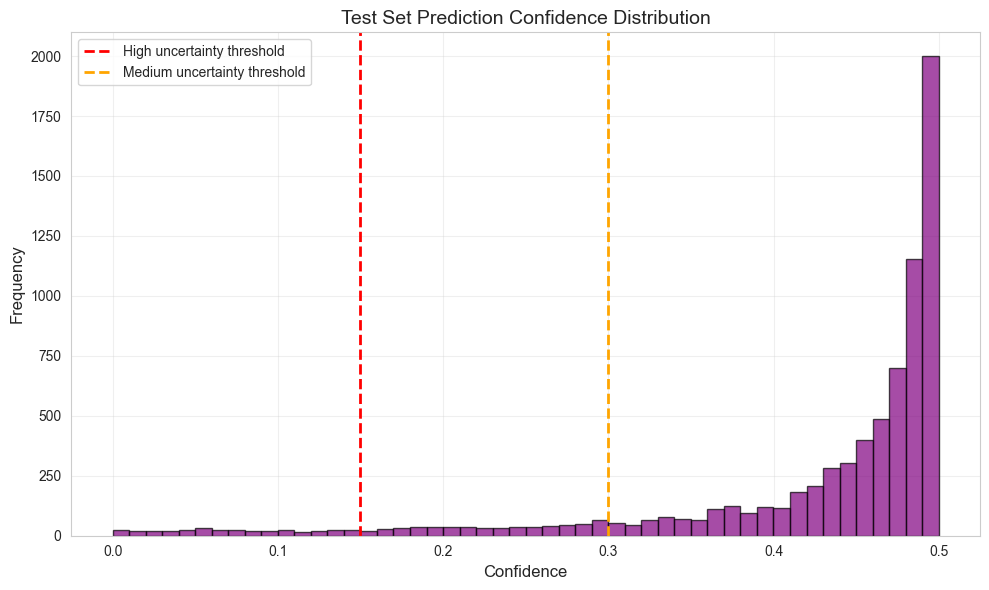

In [ ]:
# Define uncertainty zones
uncertainty_zones = {
    'high_uncertainty': test_predictions[test_predictions['confidence'] <= 0.15],
    'medium_uncertainty': test_predictions[
        (test_predictions['confidence'] > 0.15) & (test_predictions['confidence'] <= 0.3)
    ],
    'low_uncertainty': test_predictions[test_predictions['confidence'] > 0.3]
}

print("\nUncertainty Zone Breakdown:")
print("=" * 50)
for zone_name, zone_df in uncertainty_zones.items():
    print(f"{zone_name}: {len(zone_df)} accounts ({len(zone_df)/len(test_predictions)*100:.1f}%)")
    if len(zone_df) > 0:
        print(f"  Predicted good: {(zone_df['predicted_label']==1).sum()}")
        print(f"  Predicted bad: {(zone_df['predicted_label']==0).sum()}")
print("=" * 50)

# Visualize uncertainty distribution
plt.figure(figsize=(10, 6))
plt.hist(test_predictions['confidence'], bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.axvline(x=0.15, color='red', linestyle='--', linewidth=2, label='High uncertainty threshold')
plt.axvline(x=0.3, color='orange', linestyle='--', linewidth=2, label='Medium uncertainty threshold')
plt.xlabel('Confidence', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Test Set Prediction Confidence Distribution', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'test_uncertainty_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Save Model and Predictions

In [ ]:
# Save model
model.save_model(str(MODEL_DIR / 'conservative_model.cbm'))
print("✓ Saved conservative_model.cbm")

# Save as pickle for easier loading
with open(MODEL_DIR / 'conservative_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("✓ Saved conservative_model.pkl")

# Save predictions
with open(OUTPUT_DIR / 'model_predictions_test.pkl', 'wb') as f:
    pickle.dump(test_predictions, f)
print("✓ Saved model_predictions_test.pkl")

# Save as CSV
test_predictions.to_csv(OUTPUT_DIR / 'model_predictions_test.csv', index=False)
print("✓ Saved model_predictions_test.csv")

# Save uncertainty zones
with open(OUTPUT_DIR / 'uncertainty_zones.pkl', 'wb') as f:
    pickle.dump(uncertainty_zones, f)
print("✓ Saved uncertainty_zones.pkl")

# Save validation performance
validation_metrics = {
    'f1_score': f1,
    'roc_auc': roc_auc,
    'precision': precision,
    'recall': recall,
    'confusion_matrix': cm.tolist(),
    'false_positive_rate': float(cm[1, 0] / (cm[1, 0] + cm[1, 1])),
    'false_negative_rate': float(cm[0, 1] / (cm[0, 0] + cm[0, 1])),
}

import json
with open(OUTPUT_DIR / 'validation_metrics.json', 'w') as f:
    json.dump(validation_metrics, f, indent=2)
print("✓ Saved validation_metrics.json")

print("\n" + "="*50)
print("Conservative Model Training Complete!")
print("="*50)
print(f"\nModel Performance:")
print(f"  F1 Score: {f1:.4f}")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"\nUncertainty Analysis:")
print(f"  High uncertainty accounts: {len(uncertainty_zones['high_uncertainty'])}")
print(f"  Medium uncertainty accounts: {len(uncertainty_zones['medium_uncertainty'])}")
print(f"  Low uncertainty accounts: {len(uncertainty_zones['low_uncertainty'])}")
print(f"\nThese uncertainty zones will guide hypothesis generation!")

✓ Saved conservative_model.cbm
✓ Saved conservative_model.pkl
✓ Saved model_predictions_test.pkl
✓ Saved model_predictions_test.csv
✓ Saved uncertainty_zones.pkl
✓ Saved validation_metrics.json

Conservative Model Training Complete!

Model Performance:
  F1 Score: 0.8258
  ROC-AUC: 0.9747
  Precision: 0.8594
  Recall: 0.7948

Uncertainty Analysis:
  High uncertainty accounts: 331
  Medium uncertainty accounts: 570
  Low uncertainty accounts: 6657

These uncertainty zones will guide hypothesis generation!
